# **Combined dataset (FingerVein + PPG)**
The proposal (`../proposal_helpers/proposta-rivista.md`, §2) defines a **third, combined dataset** built by *pairing* a FingerVein sample with a PPG sample that share the **same sex and the same age** ("accoppiando campioni FingerVein e PPG con lo stesso sesso e la stessa età"). This combined set feeds **Model C**, the two-branch early-fusion network.

The two modalities have **no common subjects** — they are different people from different acquisition campaigns. The only thing we can align on is the **demographics**: each notebook already produces a per-subject table with `Age` + `Gender`, which is exactly the pairing key.

> **Leakage matters.** Per the proposal, the train/val/test split is done **per subject, within each modality, *before* pairing**. We pair only *inside* a given split, so a subject (FV or PPG) never leaks across splits.

# **Useful modules import**
We reuse the same loaders as notebooks 01 and 02 (PDF info table for FingerVein, `subject-info.csv` for PPG), kept self-contained here so this notebook runs on its own.

In [1]:
import io
import os
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pypdf import PdfReader
import wfdb

# **Configuration**
Both archives live in `../proposal_helpers/proj_files/`, same as the other notebooks.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ZIP_DIR = PROJECT_ROOT.parent / 'proposal_helpers' / 'proj_files'
FV_ZIP = DATA_ZIP_DIR / 'MMCBNU_6000.zip'
PPG_ZIP = DATA_ZIP_DIR / 'brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip'

assert FV_ZIP.exists(), f'FingerVein archive not found: {FV_ZIP}'
assert PPG_ZIP.exists(), f'PPG archive not found: {PPG_ZIP}'
print('FingerVein :', FV_ZIP.name)
print('PPG        :', PPG_ZIP.name)

FingerVein : MMCBNU_6000.zip
PPG        : brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip


# **The two label tables (the pairing key)**
We load the per-subject demographics from each modality and reduce them to a **common schema** `uid, age, gender`:

- **FingerVein** — parsed from the *Information table* in `Description of MMCBNU_6000.pdf` (1 row per subject `001..100`);
- **PPG** — from `subject-info.csv` (1 row per record).

Gender is already encoded as `M`/`F` in **both** datasets, so no remapping is needed.

In [3]:
def load_fv_info(zip_path):
    """Per-subject (age, gender) for FingerVein, from the description PDF inside the archive."""
    with zipfile.ZipFile(zip_path) as z:
        pdf_name = next(n for n in z.namelist() if n.lower().endswith('.pdf'))
        reader = PdfReader(io.BytesIO(z.read(pdf_name)))
    text = '\n'.join((page.extract_text() or '') for page in reader.pages)

    rows = []
    for line in text.splitlines():
        toks = line.split()
        if len(toks) >= 4 and toks[0].isdigit() and toks[1].isdigit():
            gi = next((i for i, t in enumerate(toks[2:], 2) if t in ('M', 'F')), None)
            if gi is None:
                continue
            rows.append({'uid': f'{int(toks[0]):03d}', 'age': int(toks[1]), 'gender': toks[gi]})
    return pd.DataFrame(rows)


def load_ppg_info(zip_path):
    """Per-record (age, gender) for PPG, from subject-info.csv inside the archive."""
    with zipfile.ZipFile(zip_path) as z:
        csv_name = next(n for n in z.namelist() if n.endswith('subject-info.csv'))
        df = pd.read_csv(io.BytesIO(z.read(csv_name)))
    df = df.assign(age=pd.to_numeric(df['Age [years]'], errors='coerce'))
    df = df.rename(columns={'ID': 'uid', 'Gender': 'gender'})
    df = df[['uid', 'age', 'gender']].dropna(subset=['age'])
    df['uid'] = df['uid'].astype(str)
    df['age'] = df['age'].astype(int)
    return df.reset_index(drop=True)


fv = load_fv_info(FV_ZIP)
ppg = load_ppg_info(PPG_ZIP)
print(f'FingerVein subjects : {len(fv)}  | gender {fv.gender.value_counts().to_dict()}  | age {fv.age.min()}-{fv.age.max()}')
print(f'PPG records         : {len(ppg)}  | gender {ppg.gender.value_counts().to_dict()}  | age {ppg.age.min()}-{ppg.age.max()}')
fv.head()

FingerVein subjects : 100  | gender {'M': 83, 'F': 17}  | age 16-72
PPG records         : 3888  | gender {'F': 1986, 'M': 1902}  | age 19-76


,uid,age,gender
0,001,22,F
1,002,24,M
2,003,22,M
3,004,27,M
4,005,47,M


# **How much can actually be paired?**
Pairing on **(gender, exact age)** is the strict reading of the proposal. Let's see how many demographic cells the two datasets share — this caps the diversity of the combined set.

In [4]:
fv_cells = set(zip(fv.gender, fv.age))
ppg_cells = set(zip(ppg.gender, ppg.age))
shared = sorted(fv_cells & ppg_cells)
print(f'FV (gender,age) cells   : {len(fv_cells)}')
print(f'PPG (gender,age) cells  : {len(ppg_cells)}')
print(f'shared (exact age)      : {len(shared)}')
print(shared)

FV (gender,age) cells   : 32
PPG (gender,age) cells  : 31
shared (exact age)      : 15
[('F', 21), ('F', 22), ('F', 23), ('F', 24), ('F', 25), ('F', 30), ('M', 22), ('M', 23), ('M', 24), ('M', 25), ('M', 26), ('M', 27), ('M', 29), ('M', 34), ('M', 59)]


The exact-age overlap is small, and FingerVein is heavily male-skewed. Two knobs widen the combined set without breaking the "same sex" rule:

- **`age_tol`** — allow an age difference of ±`tol` years (`0` = literal "stessa età");
- **one-to-one vs. expand** — below we draw **one** PPG record per FV subject, which keeps the combined set balanced and avoids a handful of common ages dominating. (PPG has thousands of records, so a Cartesian product per cell would explode and skew toward 20-somethings.)

# **Step 1 — per-subject split (before pairing)**
Each modality is split **independently and by subject**, so all images / records of one person stay in a single split. This is done *before* any pairing, exactly as the proposal requires, to rule out train/val/test leakage.

In [5]:
def split_by_subject(df, frac=(0.7, 0.15, 0.15), seed=0):
    """Assign each unique uid to train/val/test (per-subject, no overlap)."""
    subs = df['uid'].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    n = len(subs)
    a, b = int(frac[0] * n), int((frac[0] + frac[1]) * n)
    tag = {s: ('train' if i < a else 'val' if i < b else 'test') for i, s in enumerate(subs)}
    return df.assign(split=df['uid'].map(tag))


fv = split_by_subject(fv, seed=0)
ppg = split_by_subject(ppg, seed=0)

print('FV  split sizes :', fv.drop_duplicates('uid').split.value_counts().to_dict())
print('PPG split sizes :', ppg.drop_duplicates('uid').split.value_counts().to_dict())

FV  split sizes : {'train': 70, 'test': 15, 'val': 15}
PPG split sizes : {'train': 2721, 'test': 584, 'val': 583}


# **Step 2 — pair within each split**
For every FingerVein subject we look for PPG records of the **same gender** and an age within `age_tol`, *restricted to the same split*, and draw one at random. The result is the combined table: one row = one fused sample with a shared `age` target.

In [6]:
def make_pairs(fv, ppg, split, age_tol=1, seed=0):
    rng = np.random.default_rng(seed)
    f = fv[fv.split == split]
    p = ppg[ppg.split == split]
    pairs = []
    for _, fr in f.iterrows():
        cand = p[(p.gender == fr.gender) & (p.age.sub(fr.age).abs() <= age_tol)]
        if len(cand):
            pr = cand.iloc[int(rng.integers(len(cand)))]
            pairs.append({
                'fv_uid': fr.uid, 'ppg_uid': pr.uid,
                'gender': fr.gender,
                'age': fr.age,                 # FV age is the shared target
                'ppg_age': int(pr.age),        # kept to audit the tolerance
                'split': split,
            })
    return pd.DataFrame(pairs)


AGE_TOL = 1
combined = pd.concat(
    [make_pairs(fv, ppg, s, age_tol=AGE_TOL) for s in ('train', 'val', 'test')],
    ignore_index=True,
)

print(f'combined pairs (age_tol={AGE_TOL}) : {len(combined)} / {len(fv)} FV subjects')
print('per split :', combined.split.value_counts().to_dict())
combined.head()

combined pairs (age_tol=1) : 83 / 100 FV subjects
per split : {'train': 58, 'test': 13, 'val': 12}


,fv_uid,ppg_uid,gender,age,ppg_age,split
0,001,145059,F,22,22,train
1,002,143046,M,24,23,train
2,003,130095,M,22,21,train
3,004,138048,M,27,27,train
4,006,132105,F,24,23,train


# **Sanity checks**
Two things to verify: (i) **no subject leakage** — no FV or PPG uid appears in more than one split; (ii) the **age/gender** make-up of the combined set.

fv_uid: 0 uids spanning >1 split  -> OK
ppg_uid: 0 uids spanning >1 split  -> OK


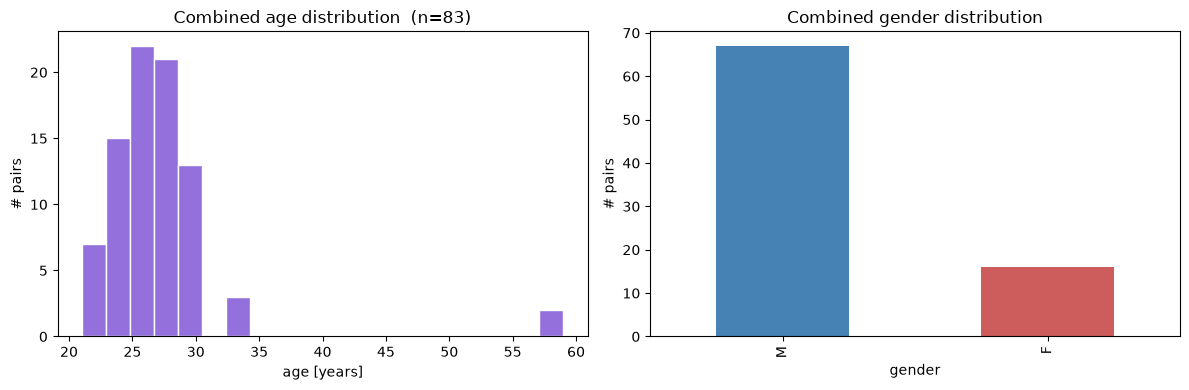

|FV age - PPG age| counts : {0: 25, 1: 58}


In [7]:
for col in ('fv_uid', 'ppg_uid'):
    spans = combined.groupby(col)['split'].nunique()
    leaked = spans[spans > 1]
    print(f'{col}: {len(leaked)} uids spanning >1 split  ->', 'OK' if leaked.empty else 'LEAK!')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(combined['age'], bins=20, color='mediumpurple', edgecolor='white')
ax1.set_title(f'Combined age distribution  (n={len(combined)})')
ax1.set_xlabel('age [years]')
ax1.set_ylabel('# pairs')

combined['gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Combined gender distribution')
ax2.set_xlabel('gender')
ax2.set_ylabel('# pairs')
plt.tight_layout()
plt.show()

# how far did the age tolerance stretch?
print('|FV age - PPG age| counts :', combined['age'].sub(combined['ppg_age']).abs().value_counts().sort_index().to_dict())

# **One fused sample, end to end**
Finally we materialize a single combined row into the two raw inputs Model C will consume: a **FingerVein image** for `fv_uid` and a **PPG waveform** for `ppg_uid`, sharing one `age` label. The loaders below are the same as in notebooks 01 and 02.

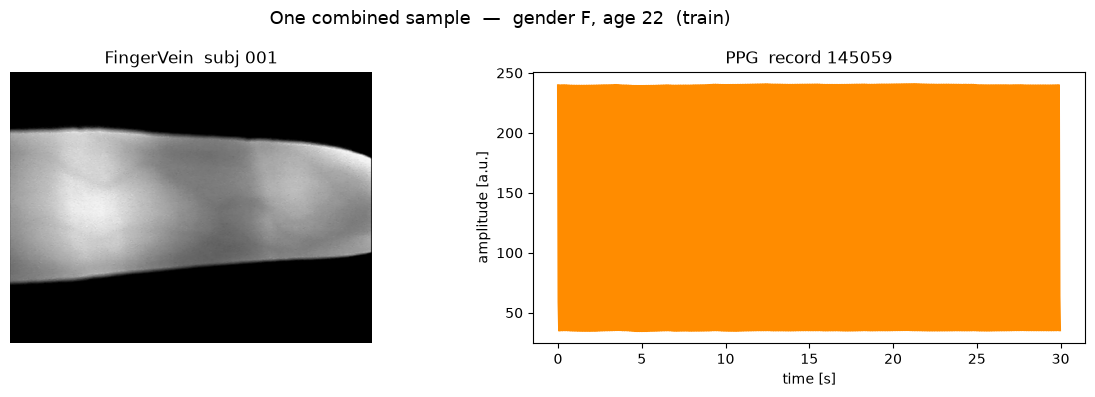

In [8]:
def load_fv_image(zip_path, subject):
    with zipfile.ZipFile(zip_path) as z:
        name = next(n for n in z.namelist()
                    if n.lower().endswith('.bmp') and n.split('/')[-3] == subject)
        return np.array(Image.open(io.BytesIO(z.read(name))))


def read_ppg(zip_path, record_id):
    with zipfile.ZipFile(zip_path) as z:
        base = next(n[:-4] for n in z.namelist()
                    if n.endswith(f'{record_id}/{record_id}_PPG.hea'))
        with tempfile.TemporaryDirectory() as td:
            stem = os.path.basename(base)
            for ext in ('.hea', '.dat'):
                with open(os.path.join(td, stem + ext), 'wb') as fh:
                    fh.write(z.read(base + ext))
            rec = wfdb.rdrecord(os.path.join(td, stem))
    return rec.p_signal.flatten(), rec.fs


row = combined.iloc[0]
img = load_fv_image(FV_ZIP, row['fv_uid'])
sig, fs = read_ppg(PPG_ZIP, row['ppg_uid'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray')
ax1.set_title(f"FingerVein  subj {row['fv_uid']}")
ax1.axis('off')
ax2.plot(np.arange(len(sig)) / fs, sig, color='darkorange')
ax2.set_title(f"PPG  record {row['ppg_uid']}")
ax2.set_xlabel('time [s]')
ax2.set_ylabel('amplitude [a.u.]')
fig.suptitle(f"One combined sample  —  gender {row['gender']}, age {row['age']}  ({row['split']})", fontsize=13)
plt.tight_layout()
plt.show()